In [10]:
import pandas as pd

from matplotlib import pyplot as plt 
%matplotlib inline

import seaborn as sb

from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# path to the file to read
pcos_file_path = 'data\data without infertility _final.csv'

pcos_data = pd.read_csv(pcos_file_path) 


## Data info

In [ ]:
# Print summary statistics in next line
pcos_data.describe()

#pcos_data.columns

In [ ]:
pcos_data.info()

In [11]:
pcos_data.columns = pcos_data.columns.str.strip()

## Cleaning data

In [ ]:
#to see empty data ; in our case it is col 42
sb.heatmap(pcos_data.isnull())

In [12]:
#dropping col that has all null values, and then id cols cause they are not needed for the clasification
#axis=1 is for col axis=0 is for rows
pcos_data.drop(["Unnamed: 42", "Sl. No", "Patient File No."], axis=1, inplace=True)

In [ ]:
sb.heatmap(pcos_data.isnull())

Changing irregural cycles values

In [13]:
pcos_data["Cycle(R/I)"] = pcos_data["Cycle(R/I)"].map({
    2: 0,  # Regular
    4: 1   # Irregular
})


playing again with visuals


In [ ]:
cols = pcos_data.select_dtypes(include=["int64", "float64"]).columns
cols = cols.drop("PCOS (Y/N)")  # don’t plot target vs itself

for label in cols:
    plt.figure(figsize=(6, 4))

    data_pcos = pcos_data[pcos_data["PCOS (Y/N)"] == 1][label]
    data_no_pcos = pcos_data[pcos_data["PCOS (Y/N)"] == 0][label]

    bins = 30

    plt.hist(data_pcos, bins=bins, alpha=0.6, density=True, label="PCOS", color="red")
    plt.hist(data_no_pcos, bins=bins, alpha=0.6, density=True, label="No PCOS", color="blue")

    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Density")
    plt.legend()
    plt.show()


#### Setting features and X

In [14]:
hormone_features = [
    "FSH(mIU/mL)",
    "LH(mIU/mL)",
    "FSH/LH",
    "AMH(ng/mL)",
    "TSH (mIU/L)",
    "PRL(ng/mL)",
    "PRG(ng/mL)"  
]


In [15]:
patient_observable_features = [
    "Cycle(R/I)",             # Regular/Irregular periods
    "Cycle length(days)",     # length of period
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"       # lifestyle activity
]

In [16]:
doctor_observable_features = [
    # Patient-reported symptoms
    "Cycle(R/I)",
    "Cycle length(days)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)",
    
    # Doctor-observed measurements
    "Weight (Kg)",
    "Height(Cm)",
    "BMI",
    "Pulse rate(bpm)",
    "RR (breaths/min)",
    "Hb(g/dl)",
    "Hip(inch)",
    "Waist(inch)",
    "Waist:Hip Ratio",
    "BP _Systolic (mmHg)",
    "BP _Diastolic (mmHg)",
    
    # Ultrasound / gynecologist measurements
    "Follicle No. (L)",
    "Follicle No. (R)",
    "Avg. F size (L) (mm)",
    "Avg. F size (R) (mm)",
    "Endometrium (mm)"
]


In [17]:
# all features except ids and target
# all_features = pcos_data.drop(columns=['PCOS (Y/N)'], axis=1)

all_features = list(pcos_data.drop(columns=['PCOS (Y/N)']).columns)

print(all_features)



['Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']


In [18]:
pcos_features = hormone_features

In [19]:
# dropna drops missing values (think of na as "not available")
pcos_data = pcos_data.dropna(
    subset=pcos_features + ["PCOS (Y/N)"]
)
#drop a row only if one of features or pcos label is missing

### Separating predictors and targets

In [20]:
# By convention, this data (features) is called X.
X = pcos_data[pcos_features]

In [ ]:
sb.heatmap(X.isnull())
plt.title("Missing values in model features")
plt.show()


In [21]:
# want to predict if paitent has pcos or no
y = pcos_data["PCOS (Y/N)"]

In [ ]:
X.describe()

In [ ]:
X.head()

In [ ]:
#just playing to see data
plt.scatter(
    pcos_data["BMI"],
    pcos_data["PCOS (Y/N)"],
    marker='+'
)

plt.xlabel("BMI")
plt.ylabel("PCOS (Y/N)")
plt.title("BMI vs PCOS")

plt.show()

In [36]:
y.value_counts()
# inbalanced data set 

PCOS (Y/N)
0    363
1    177
Name: count, dtype: int64

<Axes: ylabel='count'>

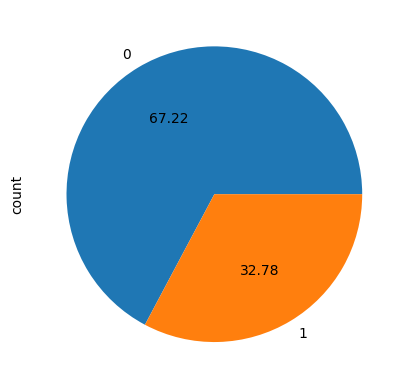

In [ ]:

y.value_counts().plot.pie(autopct='%.2f')

In [ ]:
X.dtypes


## Random Undersampling
so that we balance the set

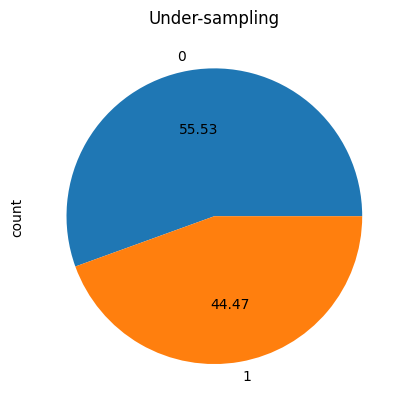

In [27]:
rus = RandomUnderSampler(sampling_strategy=0.8)
X_res, y_res = rus.fit_resample(X, y)

ax = y_res.value_counts().plot.pie(autopct='%.2f')
_ = ax.set_title("Under-sampling")

In [35]:
y_res.value_counts()

PCOS (Y/N)
0    221
1    177
Name: count, dtype: int64

## Normalize the data 

In [37]:
#create a scaler object so that we can normalize the data
scaler = StandardScaler()

# fit the scaler to the data and then transform the data
X_scaled = scaler.fit_transform(X_res)

X_scaled

array([[-0.05017804, -0.05677918, -0.07722155, ..., -0.59233059,
        -0.97311389, -0.09154971],
       [19.92210373, -0.04201374, 19.33367417, ..., -0.74618025,
         0.39401579, -0.0847756 ],
       [-0.06208989, -0.07342745, -0.0498182 , ..., -0.13453406,
         1.04765805, -0.08251757],
       ...,
       [-0.0537793 , -0.05826563, -0.08106213, ...,  0.31200517,
        -0.98574787, -0.0396149 ],
       [-0.05611418, -0.03230225, -0.09964102, ..., -0.5322917 ,
         0.32685621, -0.07122739],
       [-0.0550061 , -0.03586974, -0.09777464, ..., -0.43472851,
        -0.26029141, -0.06896935]], shape=(398, 7))

## Spliting data into train and test

In [38]:
from sklearn.model_selection import train_test_split

#the function train_test_split returns 4 diff values
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_res, test_size=0.25, random_state=67)
# if you ever want to repeat the same split, you have to repeat random_state num

# always change this value when you change it in the function so that you can log it later
test_size=0.25

## Train the model

In [39]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()

#actually train the model
logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
#predict the target on test data
predictions = logistic_model.predict(X_test)

print(predictions)

[0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1
 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0]


### Evaluation 

In [41]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy: .4f}")

Accuracy:  0.5900


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.56      0.90      0.69        51
           1       0.72      0.27      0.39        49

    accuracy                           0.59       100
   macro avg       0.64      0.58      0.54       100
weighted avg       0.64      0.59      0.54       100



## Logs how each split and feature list perfomed


In [ ]:
import os
import pandas as pd

log_path = r'logs\experiment_log.csv'

# Try reading the log; if fails, create empty DataFrame
try:
    experiment_log = pd.read_csv(log_path)
except (pd.errors.EmptyDataError, FileNotFoundError):
    experiment_log = pd.DataFrame(columns=["Features", "Test Size", "Accuracy", "Notes"])

# Your experiment info
notes = "Logistic Regression model - on all features"
new_entry = pd.DataFrame([{
    "Features": ', '.join(pcos_features),
    "Test Size": test_size,
    "Accuracy": round(accuracy, 4),
    "Notes": notes
}])

# Append new entry
experiment_log = pd.concat([experiment_log, new_entry], ignore_index=True)

# Ensure folder exists
os.makedirs(os.path.dirname(log_path), exist_ok=True)

# Save log
experiment_log.to_csv(log_path, index=False)

print("Experiment logged successfully!")
